In [44]:
from functions.internal import load_dataset_1B, normalization
from functions.SQUIC_functions import squic_fit_matrix_computation, squic_fit_computation, check_symmetric_sparse
from functions.clustering_functions import clustering_optimal_number, modularity_density, study_CC
from functions.plots import plot_timeseries, plot_knn, plot_PDens_Q
from functions.cosmograph_functions import visualize_graph, visualize_graph_external
import matplotlib.pyplot as plt
import scienceplots
plt.style.use(['science'])
import json
from scipy import sparse
from sklearn.neighbors import NearestNeighbors
import pandas as pd
import numpy as np
import os

In [45]:
def show_df(Y):
    n_users, n_days = Y.shape

    # Create labels
    day_labels = [f"Day {i}" for i in range(n_days)]
    user_labels = list(range(n_users))

    # Create the DataFrame
    df = pd.DataFrame(Y, index=user_labels, columns=day_labels)

    print(df)


def ask_yes_no(prompt, default=None):
    """
    Ask the user a yes/no question with optional default.
    """
    while True:
        answer = input(f"{prompt} (Y/N) ").strip().upper()
        if not answer and default:
            return default
        if answer in ['Y', 'N']:
            return answer
        print("Please enter 'Y' or 'N'.")


def ask_input(prompt, default=None):
    """
    Ask the user for input with optional default.
    """
    answer = input(f"{prompt} ").strip()
    if not answer and default is not None:
        return default
    return answer

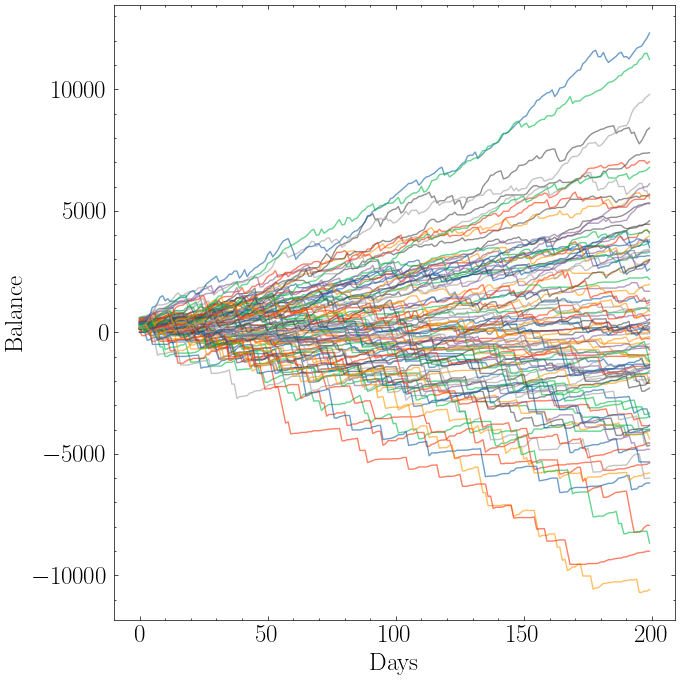

     Day 0         Day 1   Day 2   Day 3   Day 4    Day 5    Day 6    Day 7  \
0   184.44  1.844400e+02  253.63  322.82  322.82   322.82   322.82   374.37   
1   175.80  1.421085e-14   12.38   12.38   22.28    22.28    32.18    32.18   
2   142.06  1.420600e+02  142.06  142.06  198.79    56.74    66.64    66.64   
3   125.89  1.258900e+02  138.27  138.27  138.27   138.27   138.27   138.27   
4   151.13  1.827900e+02  195.17  195.17  283.92   204.50   204.50   204.50   
..     ...           ...     ...     ...     ...      ...      ...      ...   
95  411.81  4.118100e+02  578.08  647.27  702.29   738.97   738.97   839.29   
96  437.84  4.529000e+02  452.90  452.90  165.99   159.13   159.13   369.29   
97  238.28  2.382800e+02  307.47  406.85  637.58   807.53   997.13  1126.93   
98  386.67  3.866700e+02  416.62  551.40  681.07  1032.70  1054.83  1201.22   
99  297.29  2.972900e+02   12.55  147.33  272.56   398.34   525.32   679.30   

      Day 8    Day 9  ...   Day 190   Day 191   Day

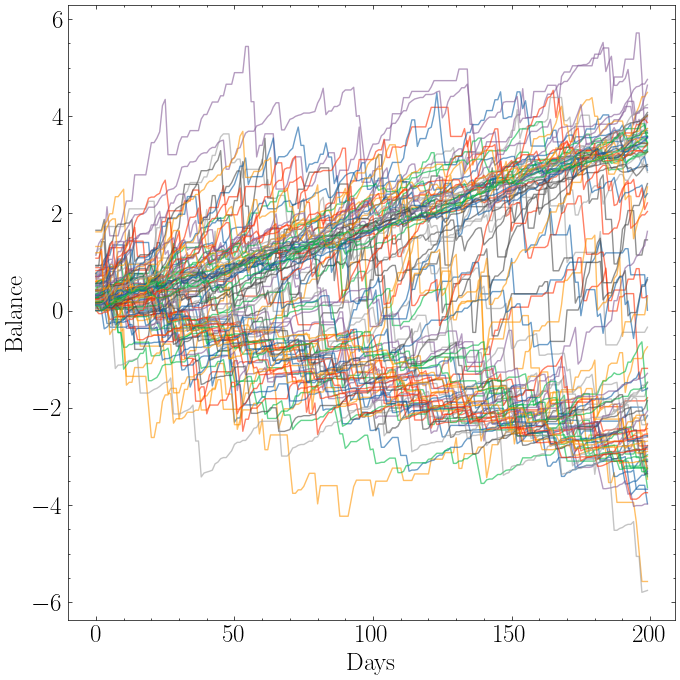

       Day 0         Day 1     Day 2     Day 3     Day 4     Day 5     Day 6  \
0   0.279429  2.794292e-01  0.384253  0.489077  0.489077  0.489077  0.489077   
1   0.142518  1.152051e-17  0.010036  0.010036  0.018062  0.018062  0.026088   
2   0.609647  6.096475e-01  0.609647  0.609647  0.853103  0.243499  0.285984   
3   0.251678  2.516778e-01  0.276428  0.276428  0.276428  0.276428  0.276428   
4   1.137171  1.375396e+00  1.468549  1.468549  2.136344  1.538752  1.538752   
..       ...           ...       ...       ...       ...       ...       ...   
95  0.320499  3.204990e-01  0.449902  0.503750  0.546571  0.575117  0.575117   
96  0.156377  1.617553e-01  0.161755  0.161755  0.059284  0.056834  0.056834   
97  0.103187  1.031870e-01  0.133150  0.176186  0.276104  0.349700  0.431807   
98  0.111915  1.119147e-01  0.120583  0.159593  0.197124  0.298897  0.305302   
99  0.091684  9.168383e-02  0.003870  0.045436  0.084057  0.122848  0.162008   

       Day 7     Day 8     Day 9  ...  

In [46]:
user_input = ask_yes_no("\nDo you want to load data?")

if user_input == 'Y':
    dimension = ask_input("Which dimension (100/1K/10K/100K/1M)?").upper()
    path = 'amlsim_data_saved'

    try:
        # Load pre-saved Y_norm
        chunk_size = 10000
        chunks = []

        for chunk in pd.read_csv(f'{path}/YNorm_{dimension}.csv', chunksize=chunk_size):
            chunks.append(chunk)

        Y_norm = pd.concat(chunks, ignore_index=True)

        print(f"Head of Y_norm df:")
        print(Y_norm.head())
        print(f"\ndimension of YNorm loaded: {Y_norm.shape}")

        std_dev = round(np.mean(np.std(Y_norm, axis=1)), 2)

        print("Mean std per row (should be 1):", std_dev)
        print("Max:", np.max(Y_norm))
        print("Min:", np.min(Y_norm))

        # Load pre-saved knn_matrix
        knn_matrix = sparse.load_npz(f'{path}/knn_matrix_{dimension}.npz')

        print("Shape KNN:", knn_matrix.shape)
        print("nnz KNN:", knn_matrix.nnz)

        # Average number of non-zeros per row
        nnz_per_row = knn_matrix.nnz / knn_matrix.shape[0]
        print("nnz per row:", round(nnz_per_row, 2))
        print("Is symmetric:", check_symmetric_sparse(knn_matrix))

        # Load pre-saved account_properties
        with open(f'{path}/account_prop_{dimension}.json', 'r') as f:
            account_prop = json.load(f)

        account_prop = {int(k): v for k, v in account_prop.items()}
        
        name = 'AMLSIM'

    except Exception as e:
        # If data are not present
        print(f"Error loading data: {e}")
        exit(1)
    
else: # Normal run
    Y, name, dimension, account_prop = load_dataset_1B()

    plot_timeseries(Y, name)

    Y = Y.T.values  # Convert to (users, days)

    show_df(Y)


    Y_norm = normalization(Y, name)
    plot_timeseries(Y_norm, name, type_df='norm')

    show_df(Y_norm)
    print(f"\ndimension of YNorm loaded: {Y_norm.shape}")

    std_dev = round(np.mean(np.std(Y_norm, axis=1)), 2)

    print("Mean std per row (should be 1):", std_dev)
    print("Max:", np.max(Y_norm))
    print("Min:", np.min(Y_norm))

    n_neigs = {
        '100' : 10,
        '1K' : 5,
        '10K' : 5,
        '100K' : 4,
        '1M' : 3
    }

    nbrs = NearestNeighbors(n_neighbors=n_neigs[dimension], metric='euclidean', n_jobs=-1)
    nbrs.fit(Y_norm)
    knn_matrix = nbrs.kneighbors_graph(Y_norm, mode='connectivity')

    print("Shape KNN:", knn_matrix.shape)
    print("nnz KNN:", knn_matrix.nnz)

    # Average number of non-zeros per row
    nnz_per_row = knn_matrix.nnz / knn_matrix.shape[0]
    print("nnz per row:", round(nnz_per_row, 2))
    print("Is symmetric:", check_symmetric_sparse(knn_matrix))

    
    # Ask user if want to save the data for next runs
    if ask_yes_no("Do you want to cache this data?") == 'Y':
        path = 'amlsim_data_saved'

        # if path does not exists, create it
        os.makedirs(path, exist_ok=True)
        
        # Save Y_norm as CSV
        pd.DataFrame(Y_norm).to_csv(f'{path}/YNorm_{dimension}.csv', index=False)
        
        # Save account_prop as json
        with open(f'{path}/account_prop_{dimension}.json', 'w') as f:
            json.dump(account_prop, f)
        
        # Save knn_matrix as npz
        sparse.save_npz(f'{path}/knn_matrix_{dimension}.npz', knn_matrix)

In [47]:
results_squic = {}

# Run SQUIC_fit
if ask_yes_no("SQUIC-Fit with bias or no?") == 'Y':

    os.makedirs(f'images/{dimension}/', exist_ok=True)

    if ask_yes_no("Do you want to visualize the results of SQUIC-Fit?") == 'Y':
        printMatrix = True

        # Print knn matrix
        plt.figure(figsize=(7, 7))
        plt.spy(knn_matrix, markersize=5)
        plt.ylabel("Users", fontsize=18)
        plt.show()
    else:
        printMatrix = False

    if ask_yes_no("Do you want to save the results of SQUIC-Fit?") == 'Y':
        save = True
    else:
        save = False
    
    if printMatrix:
        plot_knn(knn_matrix, dimension, save)
    
    squic_method = 'squic-fit-matrix'
    results_squic[squic_method] = squic_fit_matrix_computation(Y_norm, name, dimension, knn_matrix, printMatrix, save)

else:
    if ask_yes_no("Do you want to visualize the results of SQUIC-Fit?") == 'Y':
        printMatrix = True
    else:
        printMatrix = False

    if ask_yes_no("Do you want to save the results of SQUIC-Fit?") == 'Y':
        save = True
    else:
        save = False

    squic_method = 'squic-fit'
    results_squic[squic_method] = squic_fit_computation(Y_norm, name, dimension, printMatrix, save)

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           100 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      2.000000e-01 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=7.74e-04 nnz(S)/p=8.93e+01
* iter=1 time=2.85e-03 obj=7.01e+01 |delta(obj)|/obj=4.26e-01 nnz(X,L,W)/p=[8.93e+01 4.92e+01 1.00e+00] lns_iter=7 
* iter=2 time=6.40e-03 obj=6.63e+01 |delta(obj)|/obj=5.72e-02 nnz(X,L,W)/p=[8.93e+01 4.92e+01 9.41e+01] lns_iter=10 
* iter=3 time=2.73e-02 obj=6.01e+01 |delta(obj)|/o

Is G connected for l=0.2? True
Is G connected for l=0.1? True
Is G connected for l=0.09? True
Is G connected for l=0.05? True
Is G connected for l=0.01? True
For rho 0.2:
    louvain: PDensity = 0.48, Int Density = 0.57, Q = 0.52, nCluster = 4, nIsolated  = 0
    leiden: PDensity = 0.56, Int Density = 0.66, Q = 0.52, nCluster = 5, nIsolated  = 0
    dbscan: PDensity = 0.36, Int Density = 0.13, Q = 0.46, nCluster = 6, nIsolated  = 4
    spectral: PDensity = 0.35, Int Density = 0.38, Q = 0.47, nCluster = 2, nIsolated  = 0
For rho 0.1:
    louvain: PDensity = 0.39, Int Density = 0.57, Q = 0.51, nCluster = 4, nIsolated  = 0
    leiden: PDensity = 0.45, Int Density = 0.6, Q = 0.5, nCluster = 5, nIsolated  = 0
    dbscan: PDensity = 0.28, Int Density = 0.08, Q = 0.43, nCluster = 9, nIsolated  = 7
    spectral: PDensity = 0.28, Int Density = 0.32, Q = 0.45, nCluster = 2, nIsolated  = 0
For rho 0.09:
    louvain: PDensity = 0.4, Int Density = 0.51, Q = 0.51, nCluster = 4, nIsolated  = 0
    le

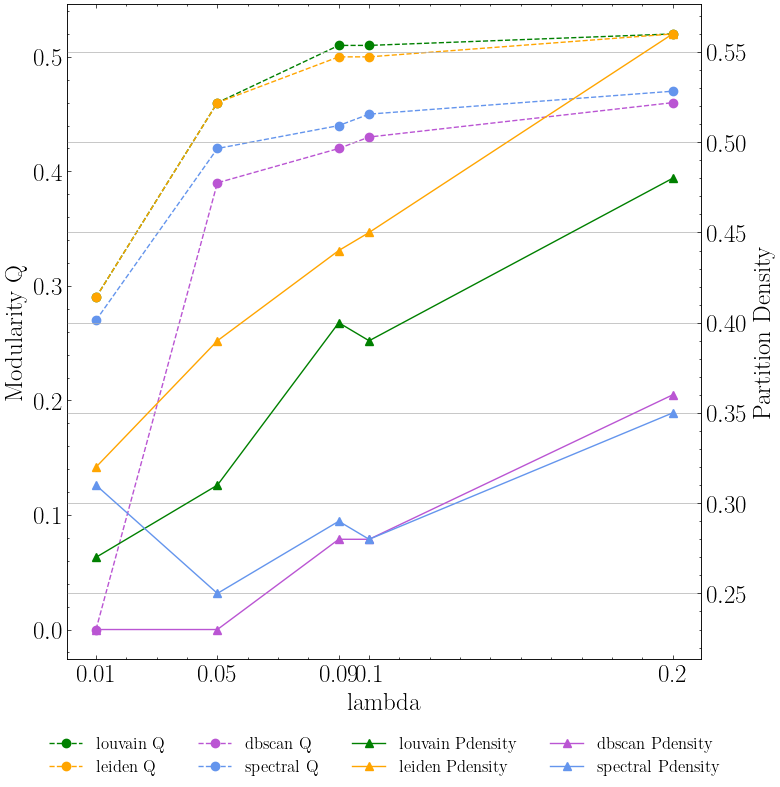

In [48]:
# Results
dict_cluster = clustering_optimal_number(dimension, results_squic, plot=False)

metrics = modularity_density(dict_cluster, results_squic, leiden=True)

for rho, data in metrics.items():
    print(f"For rho {rho}:")
    for method, results in data.items():
        print(f"    {method}: PDensity = {results['p_density']}, Int Density = {results['int_density']}, Q = {results['modularity']}, nCluster = {results['nCluster']}, nIsolated  = {results['isolated']}")

plot_PDens_Q(name, metrics, dimension, squic_method, save)

In [49]:
graph = visualize_graph_external(results_squic, squic_method, dict_cluster, account_prop)

In [41]:
rho = 0.2

In [43]:
graph[rho]['leiden']

Cosmograph(background_color='#FFFFFF', focused_point_ring_color=None, hovered_point_ring_color=None, link_colo…